tarea

Realiza la conceptualizacion de los siguientes terminos con su correspondientes ejemplo en codigo usando python y jupyter con librerias OpenCV y Scikit-image
    * Transformada Hit-or-Miss
        algoritmos de morfologia basados en la transformacion Hit-or-Miss
    * transformaciones geodesicas
        *Dilatacion geodesica
        *Erosion geodesica

## Transformada Hit-or-Miss

Concepto:
La transformada Hit-or-Miss es una operación morfológica que detecta configuraciones específicas de píxeles en una imagen binaria. Funciona mediante la superposición de un patrón estructurante sobre la imagen y buscando coincidencias exactas (hit) y ausencias (miss). Es útil para detectar esquinas, formas específicas o patrones definidos.

ejemplo:

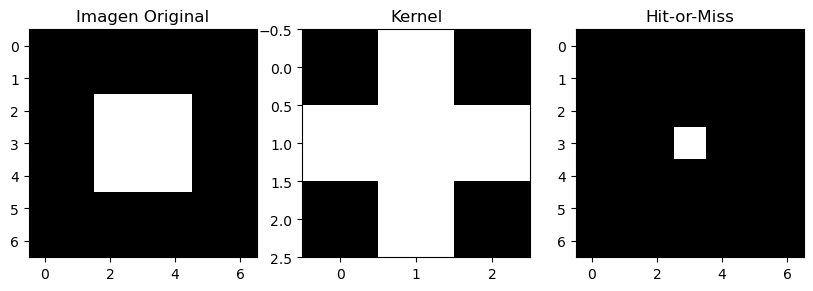

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((7, 7), dtype=np.uint8)
image[2:5, 2:5] = 1 

kernel = np.array([[0, 1, 0],
                   [1, 1, 1],
                   [0, 1, 0]], dtype=np.uint8)

hitormiss = cv2.morphologyEx(image, cv2.MORPH_HITMISS, kernel)

plt.figure(figsize=(10, 3))
plt.subplot(131), plt.imshow(image, cmap='gray'), plt.title('Imagen Original')
plt.subplot(132), plt.imshow(kernel, cmap='gray'), plt.title('Kernel')
plt.subplot(133), plt.imshow(hitormiss, cmap='gray'), plt.title('Hit-or-Miss')
plt.show()


## 2. Transformaciones Geodésicas

Las transformaciones geodésicas son operaciones morfológicas restringidas a una máscara. Se usan comúnmente en segmentación y reconstrucción de formas.

 ### 2.1 Dilatación Geodésica
 
Concepto:
La dilatación geodésica se realiza como una dilatación normal del marcador, pero limitada por una máscara. Se usa en reconstrucción morfológica para expandir regiones sin salirse del contorno definido.

Ejemplo (Scikit-image):

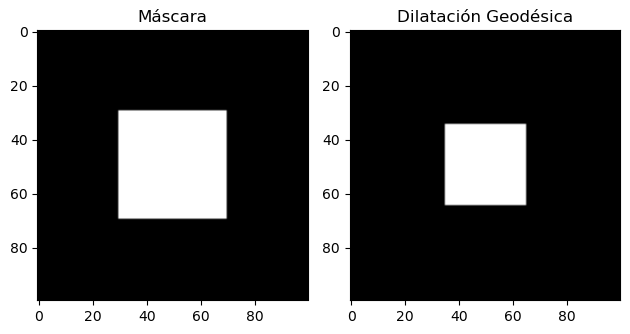

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

marker = np.zeros((100, 100), dtype=np.uint8)
mask = np.zeros((100, 100), dtype=np.uint8)

marker[45:55, 45:55] = 255
mask[30:70, 30:70] = 255

kernel = np.ones((3, 3), np.uint8)

for _ in range(10):
    marker = cv2.dilate(marker, kernel)
    marker = np.minimum(marker, mask)

plt.subplot(121)
plt.imshow(mask, cmap='gray')
plt.title('Máscara')
plt.subplot(122)
plt.imshow(marker, cmap='gray')
plt.title('Dilatación Geodésica')
plt.tight_layout()
plt.show()



### 2.2 Erosión Geodésica

Concepto:
La erosión geodésica se basa en aplicar una erosión al marcador pero restringida a no salirse de la máscara. Se usa para restringir la eliminación de píxeles solo dentro de una zona permitida.

Ejemplo

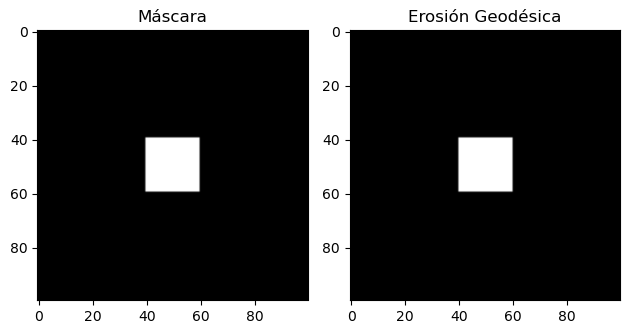

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

marker = np.zeros((100, 100), dtype=np.uint8)
mask = np.zeros((100, 100), dtype=np.uint8)

marker[30:70, 30:70] = 255
mask[40:60, 40:60] = 255

kernel = np.ones((3, 3), np.uint8)

for _ in range(10):
    marker = cv2.erode(marker, kernel)
    marker = np.maximum(marker, mask)

plt.subplot(121)
plt.imshow(mask, cmap='gray')
plt.title('Máscara')
plt.subplot(122)
plt.imshow(marker, cmap='gray')
plt.title('Erosión Geodésica')
plt.tight_layout()
plt.show()

